In [1]:
import pandas as pd
import numpy as np
#from geopy.distance import geodesic
#from geopy.geocoders import Nominatim
from datetime import datetime, timedelta
from sklearn.impute import KNNImputer, SimpleImputer
from sklego.preprocessing import RepeatingBasisFunction
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
df_AfterFirstFilling = pd.read_csv("First filling.csv")

In [3]:
df_AfterFirstFilling.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,0,2008-12-01,Albury,13.400000,22.900000,0.600000,6.828235,8.66625,W,44.000000,...,71.000000,22.000000,1007.7,1007.1,8.00,4.789474,16.900000,21.800000,No,No
1,1,2008-12-02,Albury,7.400000,32.600000,0.000000,NaN,NaN,WNW,59.000000,...,44.000000,25.000000,NaN,NaN,NaN,NaN,17.200000,24.300000,No,No
2,2,2008-12-03,Albury,12.900000,25.700000,0.000000,NaN,NaN,WSW,46.000000,...,38.000000,30.000000,NaN,NaN,3.00,4.000000,21.000000,23.200000,No,No
3,3,2008-12-04,Albury,9.200000,28.000000,0.000000,NaN,NaN,NE,43.628141,...,45.000000,16.000000,1017.6,1012.8,NaN,NaN,18.100000,26.500000,No,No
4,4,2008-12-05,Albury,15.154894,25.785654,1.936709,6.828235,8.66625,W,43.726775,...,61.722944,47.689362,1010.8,1006.0,4.92,4.801102,20.180519,24.071064,No,No


In [4]:
df_AfterFirstFilling = df_AfterFirstFilling.drop('Unnamed: 0', axis = 1)

In [5]:
df_AfterFirstFilling.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.400000,22.900000,0.600000,6.828235,8.66625,W,44.000000,W,...,71.000000,22.000000,1007.7,1007.1,8.00,4.789474,16.900000,21.800000,No,No
1,2008-12-02,Albury,7.400000,32.600000,0.000000,NaN,NaN,WNW,59.000000,NNW,...,44.000000,25.000000,NaN,NaN,NaN,NaN,17.200000,24.300000,No,No
2,2008-12-03,Albury,12.900000,25.700000,0.000000,NaN,NaN,WSW,46.000000,W,...,38.000000,30.000000,NaN,NaN,3.00,4.000000,21.000000,23.200000,No,No
3,2008-12-04,Albury,9.200000,28.000000,0.000000,NaN,NaN,NE,43.628141,SE,...,45.000000,16.000000,1017.6,1012.8,NaN,NaN,18.100000,26.500000,No,No
4,2008-12-05,Albury,15.154894,25.785654,1.936709,6.828235,8.66625,W,43.726775,ENE,...,61.722944,47.689362,1010.8,1006.0,4.92,4.801102,20.180519,24.071064,No,No


In [7]:
df_AfterFirstFilling.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [14]:
df_AfterFirstFilling.to_csv("First filling new.csv")

In [9]:
categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
non_imputed_cols = ['Date', 'Location']
numeric_cols = [col for col in df_AfterFirstFilling.columns if col not in categorical_cols + non_imputed_cols]
numeric_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [21]:
# Store imputed dataframes for each location
imputed_dfs = []

In [13]:
# Loop through each location and apply KNNImputer to numeric columns
for location, group in df_AfterFirstFilling.groupby('Location'):
    numeric_data = group[numeric_cols]
    
    imputer = KNNImputer(n_neighbors=5)
    imputed_numeric = imputer.fit_transform(numeric_data)
    
    # Restore as DataFrame
    numeric_imputed_df = pd.DataFrame(imputed_numeric, columns=numeric_cols, index=group.index)

    # Add back categorical and non-imputed columns
    for col in categorical_cols + non_imputed_cols:
        numeric_imputed_df[col] = group[col]
    
    imputed_dfs.append(numeric_imputed_df)

ValueError: Shape of passed values is (3193, 14), indices imply (3193, 16)

In [15]:
# Find locations where one or more numeric columns are entirely missing
locations_to_drop = []

for location, group in df_AfterFirstFilling.groupby('Location'):
    all_nan = group[numeric_cols].isnull().all()
    if all_nan.any():
        locations_to_drop.append(location)

print(locations_to_drop)

['Adelaide', 'Albany', 'GoldCoast', 'Katherine', 'Launceston', 'Pearce RAAF', 'Salmon Gums', 'Uluru', 'Walpole', 'Witchcliffe']


In [16]:
# Drop those locations from the DataFrame
df_filtered = df_AfterFirstFilling[~df_AfterFirstFilling['Location'].isin(locations_to_drop)]
df_filtered.isnull().sum().sum()

232467

In [17]:
df_AfterFirstFilling.size

3345580

In [18]:
df_filtered.size

2713218

In [19]:
# Find locations where one or more categorical columns are entirely missing
locations_to_drop_categorical = []

for location, group in df_AfterFirstFilling.groupby('Location'):
    all_nan_categorical = group[categorical_cols].isnull().all()
    if all_nan_categorical.any():
        locations_to_drop_categorical.append(location)

print(locations_to_drop_categorical)

['Albany']


In [20]:
# Save filtered dataset
df_filtered.to_csv("filtered_weatherAUS_afterFirstFilling.csv", index=False)

In [ ]:
# Store imputed dataframes for each location
imputed_dfs = []

In [22]:
# Loop through each location and apply KNNImputer to numeric columns
for location, group in df_filtered.groupby('Location'):
    numeric_data = group[numeric_cols]
    
    imputer = KNNImputer(n_neighbors=5)
    imputed_numeric = imputer.fit_transform(numeric_data)
    
    # Restore as DataFrame
    numeric_imputed_df = pd.DataFrame(imputed_numeric, columns=numeric_cols, index=group.index)

    # Add back categorical and non-imputed columns
    for col in categorical_cols + non_imputed_cols:
        numeric_imputed_df[col] = group[col]
    
    imputed_dfs.append(numeric_imputed_df)

In [23]:
# 4. Combine all location-wise imputed dataframes
df_imputed = pd.concat(imputed_dfs).sort_index()

In [24]:
df_imputed

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow,Date,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,W,W,WNW,No,No,2008-12-01,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,WNW,NNW,WSW,No,No,2008-12-02,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,WSW,W,WSW,No,No,2008-12-03,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,NE,SE,E,No,No,2008-12-04,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,W,ENE,NW,No,No,2008-12-05,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142299,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0.000000,24.800000,32.000000,E,SE,SE,No,No,2017-06-21,Darwin
142300,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0.000000,24.800000,32.100000,E,E,W,No,No,2017-06-22,Darwin
142301,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,1.000000,24.800000,29.200000,ESE,SE,NNW,No,No,2017-06-23,Darwin
142302,20.200000,31.700000,0.000000,5.600000,10.700000,30.000000,15.000000,7.000000,73.000000,32.000000,...,5.000000,25.400000,31.000000,ENE,ENE,NNW,No,No,2017-06-24,Darwin


In [25]:
df_imputed.isnull().sum().sum()

23872

In [26]:
total_nulls_in_categorical = df_imputed[categorical_cols].isnull().sum().sum()
total_nulls_in_categorical

23872

In [27]:
# Container for location-wise DataFrames
imputed_location_dfs = []

# Loop through each location group
for location, group in df_imputed.groupby('Location'):
    group_copy = group.copy()
    
    # Apply most_frequent imputation on categorical columns
    imputer = SimpleImputer(strategy='most_frequent')
    imputed_array = imputer.fit_transform(group_copy[categorical_cols])
    
    # Convert result back to DataFrame
    imputed_df = pd.DataFrame(imputed_array, columns=categorical_cols, index=group_copy.index)
    
    # Replace original categorical columns with imputed ones
    group_copy[categorical_cols] = imputed_df
    
    # Add to list
    imputed_location_dfs.append(group_copy)

# Combine all locations back together
df_categorical_imputed = pd.concat(imputed_location_dfs).sort_index()
df_categorical_imputed

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow,Date,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,W,W,WNW,No,No,2008-12-01,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,WNW,NNW,WSW,No,No,2008-12-02,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,WSW,W,WSW,No,No,2008-12-03,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,NE,SE,E,No,No,2008-12-04,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,W,ENE,NW,No,No,2008-12-05,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142299,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0.000000,24.800000,32.000000,E,SE,SE,No,No,2017-06-21,Darwin
142300,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0.000000,24.800000,32.100000,E,E,W,No,No,2017-06-22,Darwin
142301,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,1.000000,24.800000,29.200000,ESE,SE,NNW,No,No,2017-06-23,Darwin
142302,20.200000,31.700000,0.000000,5.600000,10.700000,30.000000,15.000000,7.000000,73.000000,32.000000,...,5.000000,25.400000,31.000000,ENE,ENE,NNW,No,No,2017-06-24,Darwin


In [28]:
df_categorical_imputed.isnull().sum().sum()

0

In [29]:
df_categorical_imputed.to_csv("categorical_imputed_per_location.csv", index=False)

In [30]:
#shift backwards for predicting latter rain
df_categorical_imputed['Rainfall_next_day'] = df_categorical_imputed['Rainfall'].shift(-1)

In [32]:
#slice of new dataframe
dfFilledNew = df_categorical_imputed[['Date', 'Rainfall', 'Rainfall_next_day']]
dfFilledNew.iloc[0:10, :]

,Date,Rainfall,Rainfall_next_day
0,2008-12-01,0.600000,0.000000
1,2008-12-02,0.000000,0.000000
2,2008-12-03,0.000000,0.000000
3,2008-12-04,0.000000,1.936709
4,2008-12-05,1.936709,0.200000
5,2008-12-06,0.200000,0.000000
6,2008-12-07,0.000000,0.000000
7,2008-12-08,0.000000,0.000000
8,2008-12-09,0.000000,1.400000
9,2008-12-10,1.400000,0.000000


In [33]:
#dropped rain tomorrow. Because in reality, this would'nt be known
df_categorical_imputed.drop('RainTomorrow', inplace = True, axis=1)
#delete last row (no next day rain)
df_categorical_imputed = df_categorical_imputed[:-1]

In [34]:
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [35]:
categorical_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [36]:
df_categorical_imputed['WindGustDir'].unique()

array(['W', 'WNW', 'WSW', 'NE', 'NNW', 'N', 'NNE', 'SW', 'ENE', 'SSE',
       'S', 'NW', 'E', 'SE', 'ESE', 'SSW'], dtype=object)

In [38]:
windGustDirHead = df_categorical_imputed['WindGustDir'].head()

In [3]:
df_categorical_imputed = pd.read_csv("categorical_imputed_per_location.csv", parse_dates=['Date'])

In [3]:
#shift backwards for predicting latter rain
df_categorical_imputed['Rainfall_next_day'] = df_categorical_imputed['Rainfall'].shift(-1)

In [4]:
#slice of new dataframe
dfFilledNew = df_categorical_imputed[['Date', 'Rainfall', 'Rainfall_next_day']]
dfFilledNew.iloc[0:10, :]

,Date,Rainfall,Rainfall_next_day
0,2008-12-01,0.600000,0.000000
1,2008-12-02,0.000000,0.000000
2,2008-12-03,0.000000,0.000000
3,2008-12-04,0.000000,1.936709
4,2008-12-05,1.936709,0.200000
5,2008-12-06,0.200000,0.000000
6,2008-12-07,0.000000,0.000000
7,2008-12-08,0.000000,0.000000
8,2008-12-09,0.000000,1.400000
9,2008-12-10,1.400000,0.000000


In [3]:
#dropped rain tomorrow. Because in reality, this would'nt be known
df_categorical_imputed.drop('RainTomorrow', inplace = True, axis=1)
#delete last row (no next day rain)
df_categorical_imputed = df_categorical_imputed[:-1]

In [4]:
dfFilled = df_categorical_imputed.copy()

In [107]:
dfFilled

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,Date,Location,Rainfall_next_day
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,W,W,WNW,No,2008-12-01,Albury,0.000000
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,WNW,NNW,WSW,No,2008-12-02,Albury,0.000000
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,WSW,W,WSW,No,2008-12-03,Albury,0.000000
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,NE,SE,E,No,2008-12-04,Albury,1.936709
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,W,ENE,NW,No,2008-12-05,Albury,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117960,19.300000,33.400000,0.000000,6.000000,11.000000,35.000000,9.000000,20.000000,63.000000,32.000000,...,1.000000,24.500000,32.300000,ENE,SE,NE,No,2017-06-20,Darwin,0.000000
117961,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0.000000,24.800000,32.000000,E,SE,SE,No,2017-06-21,Darwin,0.000000
117962,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0.000000,24.800000,32.100000,E,E,W,No,2017-06-22,Darwin,0.000000
117963,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,1.000000,24.800000,29.200000,ESE,SE,NNW,No,2017-06-23,Darwin,0.000000


In [5]:
# Begin True One-Hot Encoding

categorical_to_oneHot_encode = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

In [6]:
df_oneHot_encoded = pd.get_dummies(dfFilled, columns=categorical_to_oneHot_encode, )
df_oneHot_encoded.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm',
       ...
       'WindDir3pm_NNW', 'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE',
       'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W',
       'WindDir3pm_WNW', 'WindDir3pm_WSW'],
      dtype='object', length=105)

In [111]:
for col in df_oneHot_encoded.columns:
    print(col)

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
Date
Rainfall_next_day
Location_Albury
Location_Alice Springs
Location_Badgerys Creek
Location_Ballarat
Location_Bendigo
Location_Brisbane
Location_Cairns
Location_Canberra
Location_Cobar
Location_Coffs Harbour
Location_Dartmoor
Location_Darwin
Location_Hobart
Location_Melbourne
Location_Melbourne Airport
Location_Mildura
Location_Moree
Location_Mount Gambier
Location_Mount Ginini
Location_Newcastle
Location_Nhil
Location_Norah Head
Location_Norfolk Island
Location_Nuriootpa
Location_Penrith
Location_Perth
Location_Perth Airport
Location_Portland
Location_Richmond
Location_Sale
Location_Sydney
Location_Sydney Airport
Location_Townsville
Location_Tuggeranong
Location_Wagga Wagga
Location_Watsonia
Location_Williamtown
Location_Wollongong
Location_Woomera
WindGustDir_E
WindGustDir_ENE
WindGustDir_ESE
WindGustDir_N

In [7]:
# Do label encoding
labelEncode = LabelEncoder()

df_categorical_encoded = df_oneHot_encoded.copy()
df_categorical_encoded["RainToday"] = labelEncode.fit_transform(df_categorical_encoded["RainToday"])

In [8]:
# check if it encoded correctly
df_categorical_encoded[df_categorical_encoded["RainToday"] == 1]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
9,13.10000,30.100000,1.400000,6.844257,8.692837,28.000000,15.000000,11.000000,58.000000,27.000000,...,0,0,0,0,1,0,0,0,0,0
11,15.90000,21.700000,2.200000,6.960000,5.640000,43.795753,15.000000,13.000000,89.000000,91.000000,...,0,0,0,0,0,0,0,0,0,0
12,15.90000,18.600000,15.600000,7.503322,11.600000,61.000000,28.000000,28.000000,76.000000,93.000000,...,1,0,0,0,0,0,0,0,0,0
13,12.60000,21.000000,3.600000,6.732048,8.533286,44.000000,24.000000,20.000000,65.000000,43.000000,...,0,0,0,0,0,1,0,0,0,0
17,15.12542,25.818594,1.881495,6.732048,8.533286,43.815976,14.156566,21.204783,62.128955,48.310757,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117891,18.00000,27.900000,65.800000,7.920000,1.000000,41.000000,13.000000,20.000000,98.000000,78.000000,...,0,0,0,0,0,0,0,0,0,0
117892,21.60000,31.700000,3.400000,2.000000,10.000000,37.000000,13.000000,13.000000,78.000000,56.000000,...,0,0,0,0,0,0,0,0,0,0
117896,25.60000,33.000000,7.200000,5.600000,7.900000,39.000000,19.000000,20.000000,77.000000,55.000000,...,0,0,0,0,0,0,0,0,0,0
117899,24.70000,33.700000,1.800000,6.200000,9.700000,33.000000,9.000000,17.000000,80.000000,53.000000,...,0,0,0,0,0,0,0,0,0,0


In [114]:
df_categorical_encoded.to_csv("categorical_encoded.csv", index=False)

In [4]:
df_categorical_encoded = pd.read_csv("categorical_encoded.csv", parse_dates=['Date'])

In [15]:
for col in df_categorical_encoded.columns:
    print(col)

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
Date
Rainfall_next_day
Location_Albury
Location_Alice Springs
Location_Badgerys Creek
Location_Ballarat
Location_Bendigo
Location_Brisbane
Location_Cairns
Location_Canberra
Location_Cobar
Location_Coffs Harbour
Location_Dartmoor
Location_Darwin
Location_Hobart
Location_Melbourne
Location_Melbourne Airport
Location_Mildura
Location_Moree
Location_Mount Gambier
Location_Mount Ginini
Location_Newcastle
Location_Nhil
Location_Norah Head
Location_Norfolk Island
Location_Nuriootpa
Location_Penrith
Location_Perth
Location_Perth Airport
Location_Portland
Location_Richmond
Location_Sale
Location_Sydney
Location_Sydney Airport
Location_Townsville
Location_Tuggeranong
Location_Wagga Wagga
Location_Watsonia
Location_Williamtown
Location_Wollongong
Location_Woomera
WindGustDir_E
WindGustDir_ENE
WindGustDir_ESE
WindGustDir_N

In [13]:
#shift backwards for predicting latter rain
df_categorical_encoded.loc[:, 'Rainfall_next_day'] = df_categorical_encoded['Rainfall'].shift(-5)

In [14]:
#slice of new dataframe
dfFilledNew = df_categorical_encoded[['Date', 'Rainfall', 'Rainfall_next_5_days']]
dfFilledNew.iloc[0:32, :]

,Date,Rainfall,Rainfall_next_5_days
0,2008-12-01,0.600000,0.200000
1,2008-12-02,0.000000,0.000000
2,2008-12-03,0.000000,0.000000
3,2008-12-04,0.000000,0.000000
4,2008-12-05,1.936709,1.400000
5,2008-12-06,0.200000,0.000000
6,2008-12-07,0.000000,2.200000
7,2008-12-08,0.000000,15.600000
8,2008-12-09,0.000000,3.600000
9,2008-12-10,1.400000,0.000000


In [16]:
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Rainfall_next_30_days,Rainfall_next_25_days,Rainfall_next_20_days,Rainfall_next_15_days,Rainfall_next_10_days,Rainfall_next_5_days
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,1,0,2.020815,0.0,0.0,0.520000,0.0,0.2
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,1,0.000000,0.0,0.0,0.000000,2.2,0.0
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,1,0.000000,0.0,0.0,1.881495,15.6,0.0
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0.000000,0.0,0.0,10.600000,3.6,0.0
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0,0,0,0,0.000000,1.2,0.0,0.000000,0.0,1.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117960,19.300000,33.400000,0.000000,6.000000,11.000000,35.000000,9.000000,20.000000,63.000000,32.000000,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
117961,21.200000,32.600000,0.000000,7.600000,8.600000,37.000000,13.000000,11.000000,56.000000,28.000000,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
117962,20.700000,32.800000,0.000000,5.600000,11.000000,33.000000,17.000000,11.000000,46.000000,23.000000,...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN
117963,19.500000,31.800000,0.000000,6.200000,10.600000,26.000000,9.000000,17.000000,62.000000,58.000000,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
#delete last x row (no next day rain)
df_categorical_encoded = df_categorical_encoded[:-30]
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Rainfall_next_30_days,Rainfall_next_25_days,Rainfall_next_20_days,Rainfall_next_15_days,Rainfall_next_10_days,Rainfall_next_5_days
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,0,1,0,2.020815,0.0,0.0,0.520000,0.0,0.2
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,0,1,0.000000,0.0,0.0,0.000000,2.2,0.0
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,0,1,0.000000,0.0,0.0,1.881495,15.6,0.0
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0,0.000000,0.0,0.0,10.600000,3.6,0.0
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0,0,0,0,0.000000,1.2,0.0,0.000000,0.0,1.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117930,22.300000,34.100000,0.000000,5.000000,11.000000,30.000000,13.000000,19.000000,60.000000,55.000000,...,0,0,0,0,0.000000,0.0,0.0,0.000000,0.2,0.0
117931,23.600000,33.200000,0.000000,4.000000,10.500000,30.000000,7.000000,15.000000,75.000000,54.000000,...,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0
117932,24.000000,34.500000,0.000000,4.800000,10.600000,41.000000,7.000000,22.000000,71.000000,32.000000,...,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0
117933,22.500000,34.200000,0.000000,9.400000,10.800000,46.000000,17.000000,22.000000,60.000000,24.000000,...,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0


In [20]:
df_categorical_encoded = df_categorical_encoded.copy()

In [21]:
df_categorical_encoded.loc[:, 'Month'] = pd.to_datetime(df_categorical_encoded['Date']).dt.month

In [22]:
df_categorical_encoded

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,Rainfall_next_30_days,Rainfall_next_25_days,Rainfall_next_20_days,Rainfall_next_15_days,Rainfall_next_10_days,Rainfall_next_5_days,Month
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0,1,0,2.020815,0.0,0.0,0.520000,0.0,0.2,12
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0,0,1,0.000000,0.0,0.0,0.000000,2.2,0.0,12
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0,0,1,0.000000,0.0,0.0,1.881495,15.6,0.0,12
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0,0,0,0.000000,0.0,0.0,10.600000,3.6,0.0,12
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0,0,0,0.000000,1.2,0.0,0.000000,0.0,1.4,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117930,22.300000,34.100000,0.000000,5.000000,11.000000,30.000000,13.000000,19.000000,60.000000,55.000000,...,0,0,0,0.000000,0.0,0.0,0.000000,0.2,0.0,5
117931,23.600000,33.200000,0.000000,4.000000,10.500000,30.000000,7.000000,15.000000,75.000000,54.000000,...,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0,5
117932,24.000000,34.500000,0.000000,4.800000,10.600000,41.000000,7.000000,22.000000,71.000000,32.000000,...,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0,5
117933,22.500000,34.200000,0.000000,9.400000,10.800000,46.000000,17.000000,22.000000,60.000000,24.000000,...,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0,5


In [23]:
df_categorical_encoded["Month"].min()

1

In [24]:
df_categorical_encoded["Month"].max()

12

In [25]:
# Set up encoder
rbf = RepeatingBasisFunction(
    n_periods=12,    
    column="Month",
    input_range=(1,12),
    remainder="drop"
)

In [26]:
rbf.fit(df_categorical_encoded)

# Transform only the Month column
month_encoded = rbf.transform(df_categorical_encoded[["Month"]])

# Create new feature names
rbf_cols = [f"rbf_month_{i}" for i in range(month_encoded.shape[1])]

# Build DataFrame for RBF features
df_rbf = pd.DataFrame(month_encoded, index=df_categorical_encoded.index, columns=rbf_cols)

# Drop original Month and concat
df_final = pd.concat(
    [df_categorical_encoded.drop(columns=["Month"]), df_rbf],
    axis=1
)
df_final

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,rbf_month_2,rbf_month_3,rbf_month_4,rbf_month_5,rbf_month_6,rbf_month_7,rbf_month_8,rbf_month_9,rbf_month_10,rbf_month_11
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117930,22.300000,34.100000,0.000000,5.000000,11.000000,30.000000,13.000000,19.000000,60.000000,55.000000,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13
117931,23.600000,33.200000,0.000000,4.000000,10.500000,30.000000,7.000000,15.000000,75.000000,54.000000,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13
117932,24.000000,34.500000,0.000000,4.800000,10.600000,41.000000,7.000000,22.000000,71.000000,32.000000,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13
117933,22.500000,34.200000,0.000000,9.400000,10.800000,46.000000,17.000000,22.000000,60.000000,24.000000,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13


In [27]:
df_final.columns.tolist()

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'Date',
 'Rainfall_next_day',
 'Location_Albury',
 'Location_Alice Springs',
 'Location_Badgerys Creek',
 'Location_Ballarat',
 'Location_Bendigo',
 'Location_Brisbane',
 'Location_Cairns',
 'Location_Canberra',
 'Location_Cobar',
 'Location_Coffs Harbour',
 'Location_Dartmoor',
 'Location_Darwin',
 'Location_Hobart',
 'Location_Melbourne',
 'Location_Melbourne Airport',
 'Location_Mildura',
 'Location_Moree',
 'Location_Mount Gambier',
 'Location_Mount Ginini',
 'Location_Newcastle',
 'Location_Nhil',
 'Location_Norah Head',
 'Location_Norfolk Island',
 'Location_Nuriootpa',
 'Location_Penrith',
 'Location_Perth',
 'Location_Perth Airport',
 'Location_Portland',
 'Location_Richmond',
 'Location_Sale',
 'Location_Sydney',
 'Location_Sydney Air

In [75]:
df_final.to_csv("df_final.csv", index=False)

In [5]:
df_final = pd.read_csv("df_final.csv", parse_dates=['Date'])

In [6]:
x = df_final.copy()

In [4]:
x.drop('Rainfall_next_day', inplace = True, axis=1)
x.drop('Rainfall_next_5_days', inplace = True, axis=1)
x.drop('Rainfall_next_10_days', inplace = True, axis=1)
x.drop('Rainfall_next_15_days', inplace = True, axis=1)
x.drop('Rainfall_next_20_days', inplace = True, axis=1)
x.drop('Rainfall_next_25_days', inplace = True, axis=1)
x.drop('Rainfall_next_30_days', inplace = True, axis=1)
x.drop('Date', inplace = True, axis=1)

In [5]:
for col in x.columns:
    print(col)

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
Location_Albury
Location_Alice Springs
Location_Badgerys Creek
Location_Ballarat
Location_Bendigo
Location_Brisbane
Location_Cairns
Location_Canberra
Location_Cobar
Location_Coffs Harbour
Location_Dartmoor
Location_Darwin
Location_Hobart
Location_Melbourne
Location_Melbourne Airport
Location_Mildura
Location_Moree
Location_Mount Gambier
Location_Mount Ginini
Location_Newcastle
Location_Nhil
Location_Norah Head
Location_Norfolk Island
Location_Nuriootpa
Location_Penrith
Location_Perth
Location_Perth Airport
Location_Portland
Location_Richmond
Location_Sale
Location_Sydney
Location_Sydney Airport
Location_Townsville
Location_Tuggeranong
Location_Wagga Wagga
Location_Watsonia
Location_Williamtown
Location_Wollongong
Location_Woomera
WindGustDir_E
WindGustDir_ENE
WindGustDir_ESE
WindGustDir_N
WindGustDir_NE
WindGus

In [6]:
df_final

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,rbf_month_3,rbf_month_4,rbf_month_5,rbf_month_6,rbf_month_7,rbf_month_8,rbf_month_9,rbf_month_10,rbf_month_11,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117930,22.300000,34.100000,0.000000,5.000000,11.000000,30.000000,13.000000,19.000000,60.000000,55.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin
117931,23.600000,33.200000,0.000000,4.000000,10.500000,30.000000,7.000000,15.000000,75.000000,54.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin
117932,24.000000,34.500000,0.000000,4.800000,10.600000,41.000000,7.000000,22.000000,71.000000,32.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin
117933,22.500000,34.200000,0.000000,9.400000,10.800000,46.000000,17.000000,22.000000,60.000000,24.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin


In [7]:
x.drop('Location', inplace = True, axis=1)

In [31]:
y = df_final['Rainfall_next_day']
y

0         0.000000
1         0.000000
2         0.000000
3         1.936709
4         0.200000
            ...   
117930    0.000000
117931    0.000000
117932    0.000000
117933    0.000000
117934    0.000000
Name: Rainfall_next_day, Length: 117935, dtype: float64

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib import rcParams
import time

In [32]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [19]:
# start timer
#start_time = time.time()

#fitting the model
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

# end timer
#end_time = time.time()

#print(f"Training took {end_time - start_time:.2f} seconds")

RandomForestRegressor(n_estimators=200)

In [20]:
y_pred = rf.predict(X_test)

In [21]:
rf_MAE = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE)

Mean absolute error:  2.3232827772618267


In [22]:
rf_MSE = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE)

Mean squared error:  39.39236765486385


In [23]:
rf_RMSE = np.sqrt(rf_MSE)
print("Root mean squared error: ", rf_RMSE)

Root mean squared error:  6.276333934301444


In [10]:
y_test.mean()

1.9080951371518209

In [12]:
mae_zero_sklearn = mean_absolute_error(y_test, np.zeros_like(y_test))
print(mae_zero_sklearn)

1.9080951371518209


In [33]:
mse_zero = mean_squared_error(y_test, np.zeros_like(y_test))
print(mse_zero)

60.728964700894565


In [35]:
rmse_zero = np.sqrt(mse_zero)
print(rmse_zero)

7.7928791021608035


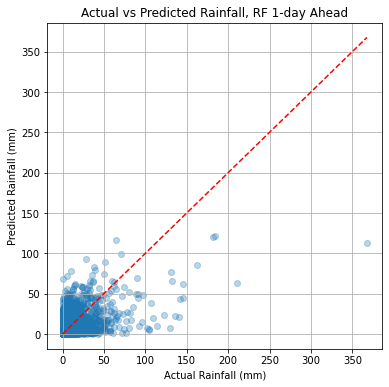

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, y_test.max()], [0, y_test.max()], '--r')
plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("Actual vs Predicted Rainfall, RF 1-day Ahead")
plt.grid(True)
plt.show()


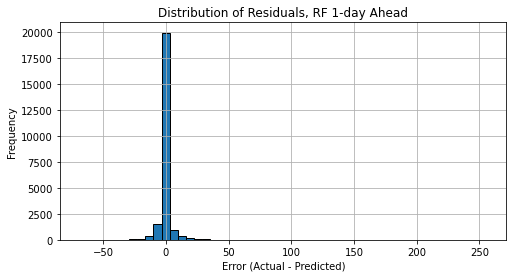

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='k')
plt.title("Distribution of Residuals, RF 1-day Ahead")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


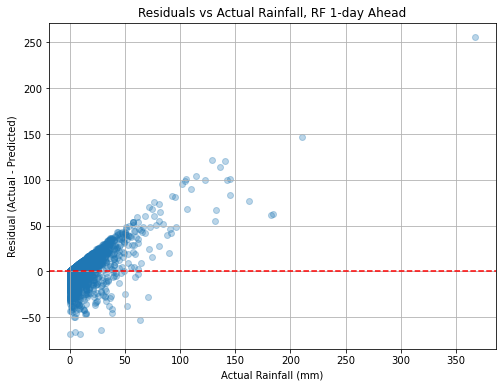

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Actual Rainfall, RF 1-day Ahead")
plt.grid(True)
plt.show()

In [28]:
# Extract one-hot encoded location columns
location_cols = [col for col in df_final.columns if col.startswith("Location_")]

In [29]:
# Recovered Location column
df_final['Location'] = df_final[location_cols].idxmax(axis=1).str.replace('Location_', '')

In [30]:
df_final

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,rbf_month_3,rbf_month_4,rbf_month_5,rbf_month_6,rbf_month_7,rbf_month_8,rbf_month_9,rbf_month_10,rbf_month_11,Location
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Albury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117930,22.300000,34.100000,0.000000,5.000000,11.000000,30.000000,13.000000,19.000000,60.000000,55.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin
117931,23.600000,33.200000,0.000000,4.000000,10.500000,30.000000,7.000000,15.000000,75.000000,54.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin
117932,24.000000,34.500000,0.000000,4.800000,10.600000,41.000000,7.000000,22.000000,71.000000,32.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin
117933,22.500000,34.200000,0.000000,9.400000,10.800000,46.000000,17.000000,22.000000,60.000000,24.000000,...,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin


In [31]:
X_test

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,rbf_month_2,rbf_month_3,rbf_month_4,rbf_month_5,rbf_month_6,rbf_month_7,rbf_month_8,rbf_month_9,rbf_month_10,rbf_month_11
94348,9.6,17.9,0.0,4.0,5.4,52.0,28.0,30.0,57.0,44.0,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
94349,6.3,23.5,0.0,4.4,13.6,41.0,30.0,17.0,52.0,30.0,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
94350,8.6,25.4,0.0,8.0,13.6,33.0,13.0,22.0,68.0,48.0,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
94351,7.6,28.1,0.0,5.2,13.3,39.0,6.0,22.0,60.0,38.0,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
94352,10.1,30.1,0.0,6.2,10.3,33.0,0.0,19.0,75.0,42.0,...,0.018316,0.000123,1.125352e-07,1.388794e-11,2.319523e-16,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117930,22.3,34.1,0.0,5.0,11.0,30.0,13.0,19.0,60.0,55.0,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13
117931,23.6,33.2,0.0,4.0,10.5,30.0,7.0,15.0,75.0,54.0,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13
117932,24.0,34.5,0.0,4.8,10.6,41.0,7.0,22.0,71.0,32.0,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13
117933,22.5,34.2,0.0,9.4,10.8,46.0,17.0,22.0,60.0,24.0,...,0.003747,0.155750,8.761382e-01,6.670044e-01,6.872200e-02,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13


In [32]:
# Select just the Location column
location_column = df_final.loc[X_test.index, 'Location']

In [33]:
# Merge with X_test
X_test_with_location = X_test.copy()
X_test_with_location['Location'] = location_column

In [34]:
# Add prediction results
X_test_with_location['Actual'] = y_test.values
X_test_with_location['Predicted'] = y_pred

In [35]:
X_test_with_location['Abs_Error'] = abs(X_test_with_location['Actual'] - X_test_with_location['Predicted'])

<AxesSubplot:title={'center':'MAE by Location, RF 1-day Ahead'}, xlabel='Location'>

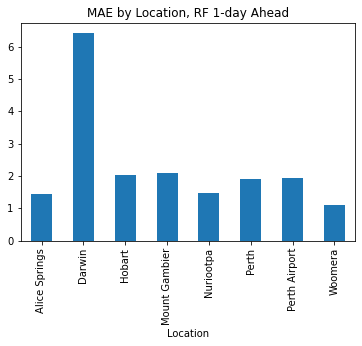

In [36]:
error_by_location = X_test_with_location.groupby('Location')['Abs_Error'].mean()
error_by_location.plot(kind='bar', title='MAE by Location, RF 1-day Ahead')

In [37]:
# Summary stats per horizon
summary = X_test_with_location.groupby("Location")["Actual"].describe()
print(summary)

                count      mean        std  min  25%  50%  75%    max
Location                                                             
Alice Springs  3040.0  0.889197   4.465629  0.0  0.0  0.0  0.0   62.0
Darwin         3162.0  5.142315  16.522864  0.0  0.0  0.0  1.8  367.6
Hobart         3193.0  1.601428   4.402172  0.0  0.0  0.0  1.0   71.6
Mount Gambier  1972.0  1.958925   4.694577  0.0  0.0  0.2  1.8   53.2
Nuriootpa      3009.0  1.390475   4.388450  0.0  0.0  0.0  0.5   76.6
Perth          3193.0  1.907235   5.789884  0.0  0.0  0.0  0.2  114.4
Perth Airport  3009.0  1.761648   5.375192  0.0  0.0  0.0  0.2   76.6
Woomera        3009.0  0.495906   2.729934  0.0  0.0  0.0  0.0   66.4


In [38]:
# Select just the Date column
date_column = df_final.loc[X_test.index, 'Date']

In [39]:
# Merge with X_test
X_test_with_date = X_test.copy()
X_test_with_date['Date'] = date_column

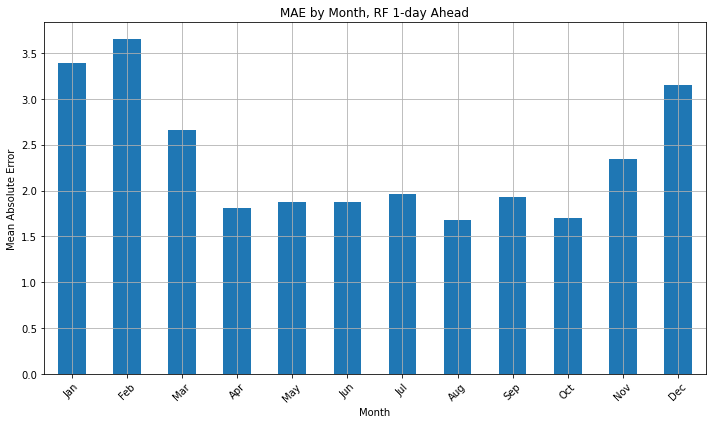

In [40]:
X_test_with_location['Month'] = pd.to_datetime(X_test_with_date['Date']).dt.month
monthly_error = X_test_with_location.groupby('Month')['Abs_Error'].mean()

# Plotting
ax = monthly_error.plot(kind='bar', figsize=(10, 6), title='MAE by Month, RF 1-day Ahead')
ax.set_xlabel("Month")
ax.set_ylabel("Mean Absolute Error")

# Replace x-tick labels with month names
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
X_test_with_location

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,rbf_month_7,rbf_month_8,rbf_month_9,rbf_month_10,rbf_month_11,Location,Actual,Predicted,Abs_Error,Month
94348,9.6,17.9,0.0,4.0,5.4,52.0,28.0,30.0,57.0,44.0,...,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Mount Gambier,0.0,0.189200,0.189200,12
94349,6.3,23.5,0.0,4.4,13.6,41.0,30.0,17.0,52.0,30.0,...,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Mount Gambier,0.0,0.207000,0.207000,12
94350,8.6,25.4,0.0,8.0,13.6,33.0,13.0,22.0,68.0,48.0,...,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Mount Gambier,0.0,0.381000,0.381000,12
94351,7.6,28.1,0.0,5.2,13.3,39.0,6.0,22.0,60.0,38.0,...,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Mount Gambier,0.0,2.618200,2.618200,12
94352,10.1,30.1,0.0,6.2,10.3,33.0,0.0,19.0,75.0,42.0,...,1.388794e-11,1.125352e-07,1.234098e-04,1.831564e-02,3.678794e-01,Mount Gambier,0.2,4.136000,3.936000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117930,22.3,34.1,0.0,5.0,11.0,30.0,13.0,19.0,60.0,55.0,...,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin,0.0,0.781500,0.781500,5
117931,23.6,33.2,0.0,4.0,10.5,30.0,7.0,15.0,75.0,54.0,...,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin,0.0,1.757309,1.757309,5
117932,24.0,34.5,0.0,4.8,10.6,41.0,7.0,22.0,71.0,32.0,...,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin,0.0,1.188800,1.188800,5
117933,22.5,34.2,0.0,9.4,10.8,46.0,17.0,22.0,60.0,24.0,...,9.582391e-04,1.808269e-06,4.618099e-10,1.596153e-14,3.205959e-13,Darwin,0.0,1.266600,1.266600,5


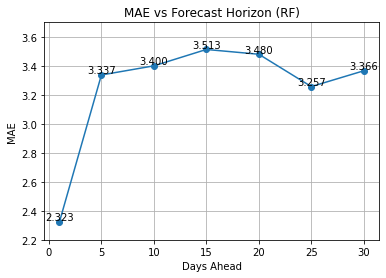

In [92]:
# Trend Over forecast horizon

# list of MAE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mae_per_horizon = [2.323, 3.337, 3.400, 3.513, 3.480, 3.257, 3.366]

plt.plot(horizons, mae_per_horizon, marker='o')
plt.title("MAE vs Forecast Horizon (RF)")
plt.xlabel("Days Ahead")
plt.ylabel("MAE")
plt.ylim(2.2, 3.7)
plt.grid(True)
for x, y in zip(horizons, mae_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


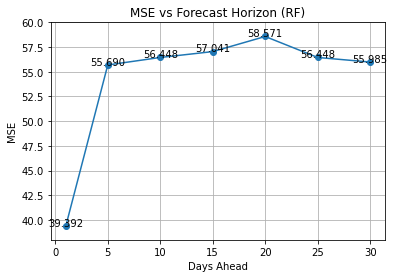

In [91]:
# Trend Over forecast horizon

# list of MSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mse_per_horizon = [39.392, 55.690, 56.448, 57.041, 58.571, 56.448, 55.985]

plt.plot(horizons, mse_per_horizon, marker='o')
plt.title("MSE vs Forecast Horizon (RF)")
plt.xlabel("Days Ahead")
plt.ylabel("MSE")
plt.ylim(38, 60)
plt.grid(True)
for x, y in zip(horizons, mse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


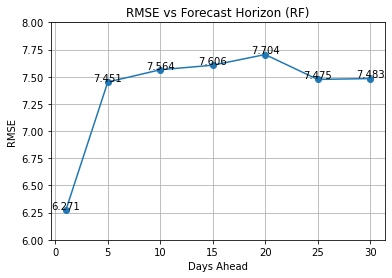

In [113]:
# Trend Over forecast horizon

# list of RMSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
rmse_per_horizon = [6.276, 7.463, 7.513, 7.552, 7.653, 7.513, 7.482]

plt.plot(horizons, rmse_per_horizon, marker='o')
plt.title("RMSE vs Forecast Horizon (RF)")
plt.xlabel("Days Ahead")
plt.ylabel("RMSE")
plt.ylim(6, 8)
plt.grid(True)
for x, y in zip(horizons, rmse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


In [44]:
for col in x.columns:
    print(col)

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
Location_Albury
Location_Alice Springs
Location_Badgerys Creek
Location_Ballarat
Location_Bendigo
Location_Brisbane
Location_Cairns
Location_Canberra
Location_Cobar
Location_Coffs Harbour
Location_Dartmoor
Location_Darwin
Location_Hobart
Location_Melbourne
Location_Melbourne Airport
Location_Mildura
Location_Moree
Location_Mount Gambier
Location_Mount Ginini
Location_Newcastle
Location_Nhil
Location_Norah Head
Location_Norfolk Island
Location_Nuriootpa
Location_Penrith
Location_Perth
Location_Perth Airport
Location_Portland
Location_Richmond
Location_Sale
Location_Sydney
Location_Sydney Airport
Location_Townsville
Location_Tuggeranong
Location_Wagga Wagga
Location_Watsonia
Location_Williamtown
Location_Wollongong
Location_Woomera
WindGustDir_E
WindGustDir_ENE
WindGustDir_ESE
WindGustDir_N
WindGustDir_NE
WindGus

In [36]:
y = df_final['Rainfall_next_5_days']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [46]:
#fitting the model
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200)

In [47]:
y_pred = rf.predict(X_test)

In [48]:
rf_MAE_5 = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE_5)

Mean absolute error:  3.3371081326960725


In [49]:
rf_MSE_5 = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE_5)

Mean squared error:  55.69017209450247


In [50]:
rf_RMSE_5 = np.sqrt(rf_MSE_5)
print("Root mean squared error: ", rf_RMSE_5)

Root mean squared error:  7.4625848132200465


In [51]:
y_test.mean()

1.908095137151821

In [15]:
mae_zero_sklearn = mean_absolute_error(y_test, np.zeros_like(y_test))
print(mae_zero_sklearn)

1.908095137151821


In [38]:
mse_zero = mean_squared_error(y_test, np.zeros_like(y_test))
print(mse_zero)

60.72896470089456


In [39]:
rmse_zero = np.sqrt(mse_zero)
print(rmse_zero)

7.792879102160803


In [40]:
y = df_final['Rainfall_next_10_days']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [54]:
#fitting the model
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200)

In [55]:
y_pred = rf.predict(X_test)

In [56]:
rf_MAE_10 = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE_10)

Mean absolute error:  3.400059257666171


In [57]:
rf_MSE_10 = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE_10)

Mean squared error:  56.44818163579553


In [58]:
rf_RMSE_10 = np.sqrt(rf_MSE_10)
print("Root mean squared error: ", rf_RMSE_10)

Root mean squared error:  7.513200492186771


In [18]:
mae_zero_sklearn = mean_absolute_error(y_test, np.zeros_like(y_test))
print(mae_zero_sklearn)

1.9080696994106923


In [42]:
mse_zero = mean_squared_error(y_test, np.zeros_like(y_test))
print(mse_zero)

60.728949438249884


In [43]:
rmse_zero = np.sqrt(mse_zero)
print(rmse_zero)

7.792878122892073


In [44]:
y = df_final['Rainfall_next_15_days']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [61]:
#fitting the model
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200)

In [62]:
y_pred = rf.predict(X_test)

In [63]:
rf_MAE_15 = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE_15)

Mean absolute error:  3.5131312424004726


In [64]:
rf_MSE_15 = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE_15)

Mean squared error:  57.04123615197089


In [65]:
rf_RMSE_15 = np.sqrt(rf_MSE_15)
print("Root mean squared error: ", rf_RMSE_15)

Root mean squared error:  7.552564872410623


In [21]:
mae_zero_sklearn = mean_absolute_error(y_test, np.zeros_like(y_test))
print(mae_zero_sklearn)

1.9073235256709202


In [46]:
mse_zero = mean_squared_error(y_test, np.zeros_like(y_test))
print(mse_zero)

60.71581678042989


In [47]:
rmse_zero = np.sqrt(mse_zero)
print(rmse_zero)

7.792035470942743


In [48]:
y = df_final['Rainfall_next_20_days']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [69]:
#fitting the model
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200)

In [70]:
y_pred = rf.predict(X_test)

In [71]:
rf_MAE_20 = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE_20)

Mean absolute error:  3.479755330476969


In [72]:
rf_MSE_20 = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE_20)

Mean squared error:  58.57072992471509


In [73]:
rf_RMSE_20 = np.sqrt(rf_MSE_20)
print("Root mean squared error: ", rf_RMSE_20)

Root mean squared error:  7.65315163345893


In [24]:
mae_zero_sklearn = mean_absolute_error(y_test, np.zeros_like(y_test))
print(mae_zero_sklearn)

1.9068826048246916


In [50]:
mse_zero = mean_squared_error(y_test, np.zeros_like(y_test))
print(mse_zero)

60.71123120362912


In [51]:
rmse_zero = np.sqrt(mse_zero)
print(rmse_zero)

7.791741217701543


In [52]:
y = df_final['Rainfall_next_25_days']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [76]:
#fitting the model
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200)

In [77]:
y_pred = rf.predict(X_test)

In [78]:
rf_MAE_25 = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE_25)

Mean absolute error:  3.25689132923023


In [79]:
rf_MSE_25 = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE_25)

Mean squared error:  56.4479339101571


In [80]:
rf_RMSE_25 = np.sqrt(rf_MSE_25)
print("Root mean squared error: ", rf_RMSE_25)

Root mean squared error:  7.513184006142609


In [27]:
mae_zero_sklearn = mean_absolute_error(y_test, np.zeros_like(y_test))
print(mae_zero_sklearn)

1.9068826048246916


In [54]:
mse_zero = mean_squared_error(y_test, np.zeros_like(y_test))
print(mse_zero)

60.71123120362911


In [55]:
rmse_zero = np.sqrt(mse_zero)
print(rmse_zero)

7.791741217701542


In [56]:
y = df_final['Rainfall_next_30_days']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

In [84]:
#fitting the model
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200)

In [85]:
y_pred = rf.predict(X_test)

In [86]:
rf_MAE_30 = mean_absolute_error(y_test, y_pred)
print("Mean absolute error: ", rf_MAE_30)

Mean absolute error:  3.365898315958975


In [87]:
rf_MSE_30 = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", rf_MSE_30)

Mean squared error:  55.98473939836697


In [88]:
rf_RMSE_30 = np.sqrt(rf_MSE_30)
print("Root mean squared error: ", rf_RMSE_30)

Root mean squared error:  7.482295062236384


In [30]:
mae_zero_sklearn = mean_absolute_error(y_test, np.zeros_like(y_test))
print(mae_zero_sklearn)

1.9068826048246916


In [58]:
mse_zero = mean_squared_error(y_test, np.zeros_like(y_test))
print(mse_zero)

60.71123120362911


In [59]:
rmse_zero = np.sqrt(mse_zero)
print(rmse_zero)

7.791741217701542
